# Train a MNIST model with PyTorch and deploy to Azure Functions

---

This notebook's CI test result for eu-west-1 is as follows. CI test results in other regions can be found at the end of the notebook. 

![This us-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-1/multicloud|train_and_deploy|pytorch|mnist-train-using-pytorch.ipynb)

---

## Overview

This notebook demonstrate how to train a model using Amazon SageMaker and deploy it to Azure Functions. This approach is beneficial if you use AWS services for ML for its most comprehensive set of features, yet you need to run your model in another cloud provider in situations for example, you might have acquired a company that was already running on a different cloud provider, or you may have a workload that generates value from unique capabilities provided by AWS. Another example is independent software vendors (ISVs) that make their products and services available in different cloud platforms to benefit their end customers. Or an organization may be operating in a Region where a primary cloud provider is not available, and in order to meet the data sovereignty or data residency requirements, they can use a secondary cloud provider.

In this notebook, we use PyTorch with Amazon Sagemaker to train a model to classify handwritten digits. Once trained, we export the model to an ONNX format and deploy it to Azure functions. To train the model, we use the popular MNIST dataset for training the model. 
MNIST is a subset of a larger set available from NIST. It contains 70000 labelled grayscale images each of size 28x28 pixels. The dataset is split into sets of 60000 training images and 10000 test images.
---

## Prerequisites
* Access to Azure and credentials for a service principal that has permissions to create and manage Azure Functions and associate resources


## Setup

### Install Dependencies

In [2]:
pip install torchvision onnx onnxruntime

  Obtaining dependency information for torchvision from https://files.pythonhosted.org/packages/84/eb/4f6483ae9094e164dc5b9b792e377f7d37823b0bedc3eef3193d416d2bb6/torchvision-0.16.0-cp310-cp310-manylinux1_x86_64.whl.metadata
  Obtaining dependency information for onnx from https://files.pythonhosted.org/packages/e6/74/522f651adbcd4b6d359b1a3e381185f8e1cd0ada8e9a97465a1990855dff/onnx-1.15.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
  Obtaining dependency information for onnxruntime from https://files.pythonhosted.org/packages/e0/c1/236fe9621584f32ffd6c1eeba4005f1c2932d2e21ef901c321ae51b9219d/onnxruntime-1.16.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
  Obtaining dependency information for torch==2.1.0 from https://files.pythonhosted.org/packages/6d/13/b5e8bacd980b2195f8a1741ce11cbb9146568607795d5e4ff510dcff1064/torch-2.1.0-cp310-cp310-manylinux1_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 25.6 MB/s e

## Parameters

Start with setting up basic configuration we would use throughout this notebook. This includes - 
* The Execution role that provides SageMaker permissions to access the input training and test data in the S3 bucket in your account.
* The default region for SageMaker
* The bucket and prefix where would be store the input dataset and where SageMaker would store the output model artifacts

In [3]:
import sagemaker
import boto3
import os

execution_role = sagemaker.get_execution_role()
region = boto3.Session().region_name
session = sagemaker.Session()
bucket = session.default_bucket()
prefix = "sagemaker/mnist-pytorch"

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /root/.config/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /root/.config/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /root/.config/sagemaker/config.yaml


## Training

Amazon SageMaker provides pre-built Docker images for most common machine learning frameworks, such as PyTorch, TensorFlow, PyTorch, and Chainer. These images include the deep learning framework and any other dependencies needed to run training and inference. In this example we use the pre-built image for PyTorch framework to train our model.

The [Amazon SageMaker Python SDK](https://github.com/aws/sagemaker-python-sdk#installing-the-sagemaker-python-sdk") makes it easier to train and deploy models with these deep learning frameworks.


Training a model with PyTorch involves the following steps - 
>1. Prepare a Training Script - A typical training script loads data from the input channels, configures training with hyperparameters, trains a model, and saves a model to model_dir so that it can be deployed for inference later.
>
>2. Create an Estimator - To run our training script on Amazon SageMaker, we create a PyTorch estimator
>
>3. Start training job using the fit method on the estimator - Start your training script by calling fit on an PyTorch Estimator. For what arguments can be passed into fit, see the [API reference](https://sagemaker.readthedocs.io/en/stable/estimators.html#sagemaker.estimator.Framework).

### The Training Script (train.py)

A typical training script loads data from the input channels, configures training with hyperparameters, trains a model, and saves a model to model_dir so that it can be deployed for inference later. Hyperparameters are passed to your script as arguments and can be retrieved with an `argparse.ArgumentParser` instance. 

Our script is adapted from the PyTorch MNIST example [here](https://github.com/apache/PyTorch/blob/master/example/gluon/mnist/mnist.py). 

In the training script we use the `export` function to export both the model architecture and the model parameters. We write these files to the `/opt/ml/model` directory of the container. When training completes, SageMaker  copies these files as a single object in compressed tar format to the S3 output location that we specify when we define the estimator.

Because the container imports your training script, always put your training code in a main guard `(if __name__=='__main__':)` so that the container does not inadvertently run your training code at the wrong point in execution.

In [4]:
!pygmentize 'code/train.py'

from __future__ import print_function
import argparse
import os
import json
import os
import logging
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR


logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)
logger.addHandler(logging.StreamHandler(sys.stdout))


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x

### Dataset

Download the data using `torchvision.datasets` module and upload it to our Amazon S3 location. We pass this location to the Estimator class when we start the training

In [5]:
from torchvision.datasets import MNIST
from torchvision import transforms
import os


os.makedirs("data", exist_ok=True)

MNIST.mirrors = [
    f"https://sagemaker-example-files-prod-{region}.s3.amazonaws.com/datasets/image/MNIST/"
]

MNIST(
    "data",
    download=True,
    transform=transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
    ),
)


100%|██████████| 9912422/9912422 [00:00<00:00, 34795670.47it/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 14131555.51it/s]

Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 105356114.08it/s]

Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw


100%|██████████| 4542/4542 [00:00<00:00, 2906259.16it/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [6]:
inputs = session.upload_data(path="data", bucket=bucket, key_prefix=prefix)
print(f"Dataset uploaded to {inputs}")

Dataset uploaded to s3://sagemaker-eu-west-1-526345557466/sagemaker/mnist-pytorch


### The PyTorch Estimator Class

The [Amazon SageMaker Python SDK](https://sagemaker.readthedocs.io/") includes the PyTorch Estimator class that makes running training job using the SageMaker open source PyTorch container easier. 

We define the Estimator providing the following key inputs - 

* The name and location of our training script.
* The IAM Role that grants SageMaker permissions to access our data in our input S3 bucket
* The version of python and PyTorch framework - SageMaker uses this information to get the pre-built image from the Elastic Container registry (ECR)
* The compute resources that we want SageMaker to use for model training. Compute resources are machine learning (ML) compute instances that are managed by SageMaker.
* The URL of the S3 bucket where we store the output of the job.

We also provide our training script as the entry point to the training estimator

In [7]:
from sagemaker.pytorch import PyTorch

output_location = f"s3://{bucket}/{prefix}/output"
print(f"training artifacts will be uploaded to: {output_location}")

hyperparameters={
    "batch-size": 100,
    "epochs": 1,
    "lr": 0.1,
    "gamma": 0.9,
    "log-interval": 100,
    "save-model": True
}


instance_type = "ml.c4.xlarge"
#instance_type = "local"
estimator = PyTorch(
    entry_point="train.py",
    source_dir="code",  # directory of your training script
    role=execution_role,
    framework_version="1.13",
    py_version="py39",
    instance_type=instance_type,
    instance_count=1,
    volume_size=250,
    output_path=output_location,
    hyperparameters=hyperparameters
)

training artifacts will be uploaded to: s3://sagemaker-eu-west-1-526345557466/sagemaker/mnist-pytorch/output
sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /root/.config/sagemaker/config.yaml


### Calling the Fit method
Once we have defined the estimator, we can start training by calling the `fit()` method on the estimator, providing the . When we call the `fit` method Amazon SageMaker starts a training job using our script as training code

In [8]:
estimator.fit(inputs = {
    'training': f"{inputs}",
    'testing':  f"{inputs}"
})

Using provided s3_resource


INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating training-job with name: pytorch-training-2023-11-09-14-42-45-639


2023-11-09 14:42:45 Starting - Starting the training job...
2023-11-09 14:43:00 Starting - Preparing the instances for training......
2023-11-09 14:44:00 Downloading - Downloading input data...
2023-11-09 14:44:35 Training - Downloading the training image.........
2023-11-09 14:45:56 Training - Training image download completed. Training in progress.bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
2023-11-09 14:46:04,016 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.training
2023-11-09 14:46:04,018 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2023-11-09 14:46:04,020 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2023-11-09 14:46:04,030 sagemaker_pytorch_container.training INFO     Block until all host DNS lookups succeed.
2023-11-09 14:46:04,035 sagemaker_pytorch_container.training INFO     Invoking user trai

Once the PyTorch model has been trained, the output would be available in the designated output bucket. The model artifacts are store in a file with a name `model.tar.gz`. We can get the exact location of the model output using `estimator.model_data`

## Export Model to ONNX

The Open Neural Network Exchange (ONNX) is an open format used to represent machine learning models. The PyTorch module `torch.onnx` can be used to export our model to ONNX. A model is ONNX format can be consumed by many [runtimes that support ONNX](https://onnx.ai/supported-tools.html#deployModel). The benefit of ONNX models is that they can be moved between frameworks with ease.


We included the below code snippet that exports our trained model into ONNX format in our training script. We can this function at the end of training. The code uses the `export` function in the `torch.onnx` module. The function expects along with the model `state_dict` the input and output size and shapes.

```
def export_to_onnx(model, model_dir, device):
    logger.info("Exporting the model to onnx.")
    dummy_input = torch.randn(1, 1, 28, 28).to(device)
    input_names = [ "input_0" ]
    output_names = [ "output_0" ]
    path = os.path.join(model_dir, 'mnist-pytorch.onnx')
    torch.onnx.export(model, dummy_input, path, verbose=True, input_names=input_names, output_names=output_names)
```
When the training job finishes, Amazon SageMaker copies the exported file from the `model_dir` of the training container to the specified output location in Amazon S3

We download the model archive from the S3 location to a local directory on our SageMaker Studio Notebook instance and unpack it.

In [9]:
import tarfile

model_dir = "model"
model_zip = "model.tar.gz"
model_onnx_file = "mnist-pytorch.onnx"
os.makedirs(model_dir, exist_ok=True)

local_model_file = f'{model_dir}/{model_zip}'
model_bucket,model_key = estimator.model_data.split('/',2)[-1].split('/',1)
s3 = boto3.client("s3")
s3.download_file(model_bucket,model_key,local_model_file)

model_tar = tarfile.open(local_model_file)
model_file_name = model_tar.next().name
model_tar.extractall(model_dir)
model_tar.close()

Our PyTorch model archive contains the following two files our training script saved during the training process. 
* The PyTorch model file - `model.pth`
* The Exported ONNX model file - `mnist-pytorch.onnx`

After extracing the onnx model from our model archive, we can check the consistency of the onnx model using the `check_model` function in the `onnx.checker` module.

Once validated, we use the exported ONNX model file in the subsequent steps where we package and deploy to Azure functions. 

In [10]:
import onnx

onnx_model = onnx.load(f"{model_dir}/{model_onnx_file}")
onnx.checker.check_model(onnx_model)

## Package the Model

We use zip deployment method to publish our code to Azure functions. In order to do that we need to package our onnx model file created above and our functionapp python code in a zip file. The artifacts required to deploy the function code are in the `functionapp` directory

In [11]:
!pygmentize functionapp/mnist-onnx/function_app.py

import logging
import azure.functions as func
import numpy as np
import os
import onnxruntime as ort
import json


app = func.FunctionApp()

def preprocess(input_data_json):
    # convert the JSON data into the tensor input
    return np.array(input_data_json['data']).astype('float32')
    
def run_model(model_path, req_body):
    session = ort.InferenceSession(model_path)
    input_data = preprocess(req_body)
    logging.info(f"Input Data shape is {input_data.shape}.")
    input_name = session.get_inputs()[0].name  # get the id of the first input of the model   
    try:
        result = session.run([], {input_name: input_data})
    except (RuntimeError) as e:
        print("Shape={0} and error={1}".format(input_data.shape, e))
    return result[0] 

def get_model_path():
    d=os.path.dirname(os.path.abspath(__file__))
    return os.path.join(d , './model/mnist-pytorch.onnx')

@app.function_name(name="mnist_classify")
@app.route(route="classify", auth_level=func.AuthLevel.ANONYMOUS)


In [12]:
import shutil
from zipfile import ZipFile
import pathlib


onnx_model = f"{model_dir}/{model_onnx_file}"

os.makedirs(f"functionapp/mnist-onnx/{model_dir}", exist_ok=True)
shutil.copyfile(onnx_model, f'functionapp/mnist-onnx/{onnx_model}')
src_path = "functionapp/mnist-onnx/"
function_archive = 'functionapp/mnist-onnx.zip'
with ZipFile(function_archive, "w") as archive_file:
    for dirpath, dirnames, filenames in os.walk(src_path):
        for filename in filenames:
            file_path = os.path.join(dirpath, filename)
            archive_file_path = os.path.relpath(file_path, src_path)
            archive_file.write(file_path, archive_file_path)


## Deploy the model

### Install the Azure CLI and utility libraries

In this section, we create an Azure functionapp (along with prerequisite resources). We then publish our model and our inference code to the functionapp

As a first step, we install the Azure CLI

In [13]:
!pip install -q azure-cli

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spyder 5.3.3 requires pyqt5<5.16, which is not installed.
spyder 5.3.3 requires pyqtwebengine<5.16, which is not installed.
jupyterlab 3.4.4 requires jupyter-server~=1.16, but you have jupyter-server 2.7.3 which is incompatible.
jupyterlab-server 2.10.3 requires jupyter-server~=1.4, but you have jupyter-server 2.7.3 which is incompatible.
notebook 6.5.6 requires jupyter-client<8,>=5.3.4, but you have jupyter-client 8.4.0 which is incompatible.
notebook 6.5.6 requires pyzmq<25,>=17, but you have pyzmq 25.1.1 which is incompatible.
panel 0.13.1 requires bokeh<2.5.0,>=2.4.0, but you have bokeh 3.3.0 which is incompatible.
spyder 5.3.3 requires ipython<8.0.0,>=7.31.1, but you have ipython 8.16.1 which is incompatible.
spyder 5.3.3 requires pylint<3.0,>=2.5.0, but you have pylint 3.0.1 which is incompatible.

[notice] 

### Sign in to your Azure Account

Before we can start using Azure CLI, we need to sign in to Azure using the `az login` command. This will allow us to interactively login to our Azure account. Once we entered the code into the `devicelogin` url, we are directed to Microsoft login website where we can enter our Azure account credentials to login to Azure. When the authentication is successful you see a message like below - 

<img src="azure_cli_success.jpg" alt="drawing" style="width:400px;"/>

In [23]:
!az login

To sign in, use a web browser to open the page https://microsoft.com/devicelogin and enter the code GSKY6GM8H to authenticate.
[
  {
    "cloudName": "AzureCloud",
    "homeTenantId": "af0ebd71-7908-445c-8eb0-52d667604ec9",
    "id": "ea4a16a6-4e78-4d52-b0d3-ffa4ab51ea20",
    "isDefault": true,
    "managedByTenants": [],
    "name": "Azure subscription 1",
    "state": "Enabled",
    "tenantId": "af0ebd71-7908-445c-8eb0-52d667604ec9",
    "user": {
      "name": "raja.vaidyanathan@gmail.com",
      "type": "user"
    }
  }
]


### Setup

Next we configure a few variables that we use in Azure CLI commands to create the Azure funtionapp and the prerequisites resources.

we use a random suffix to ensure unique names for resources wherever neccessary

In [24]:
import random

random_suffix = str(random.randint(10000,99999))
resource_group_name = f"multicloud-{random_suffix}-rg"
storage_account_name = f"multicloud{random_suffix}"
location = "ukwest"
sku_storage = "Standard_LRS"
functions_version = "4"
python_version = "3.9"
function_app = f"multicloud-mnist-{random_suffix}"

Once our environment is setup, we proceed to issue commands to create the neccessary resources as below - 

>1. A Resource group
>2. A Storage account for the functionapp
>3. An Azure functionappation

### Create a Resource Group

In [25]:
!az group create --name {resource_group_name} --location {location}

{
  "id": "/subscriptions/ea4a16a6-4e78-4d52-b0d3-ffa4ab51ea20/resourceGroups/multicloud-15885-rg",
  "location": "ukwest",
  "managedBy": null,
  "name": "multicloud-15885-rg",
  "properties": {
    "provisioningState": "Succeeded"
  },
  "tags": null,
  "type": "Microsoft.Resources/resourceGroups"
}


### Create Storage Account

In [26]:
!az storage account create --name {storage_account_name} --resource-group {resource_group_name} --location {location} --sku {sku_storage}

The public access to all blobs or containers in the storage account will be disallowed by default in the future, which means default value for --allow-blob-public-access is still null but will be equivalent to false.
{\ Finished ..
  "accessTier": "Hot",
  "allowBlobPublicAccess": true,
  "allowCrossTenantReplication": null,
  "allowSharedKeyAccess": null,
  "allowedCopyScope": null,
  "azureFilesIdentityBasedAuthentication": null,
  "blobRestoreStatus": null,
  "creationTime": "2023-11-09T15:11:16.277890+00:00",
  "customDomain": null,
  "defaultToOAuthAuthentication": null,
  "dnsEndpointType": null,
  "enableHttpsTrafficOnly": true,
  "enableNfsV3": null,
  "encryption": {
    "encryptionIdentity": null,
    "keySource": "Microsoft.Storage",
    "keyVaultProperties": null,
    "requireInfrastructureEncryption": null,
    "services": {
      "blob": {
        "enabled": true,
        "keyType": "Account",
        "lastEnabledTime": "2023-11-09T15:11:16.574748+00:00"
      },
      "f

### Create the function app

In [27]:
!az functionapp create --name {function_app} --resource-group {resource_group_name} --storage-account {storage_account_name}  --consumption-plan-location "{location}" --os-type Linux --runtime python --runtime-version {python_version} --functions-version {functions_version}

Your Linux function app 'multicloud-mnist-15885', that uses a consumption plan has been successfully created but is not active until content is published using Azure Portal or the Functions Core Tools.
Application Insights "multicloud-mnist-15885" was created for this Function App. You can visit https://portal.azure.com/#resource/subscriptions/ea4a16a6-4e78-4d52-b0d3-ffa4ab51ea20/resourceGroups/multicloud-15885-rg/providers/microsoft.insights/components/multicloud-mnist-15885/overview to view your Application Insights component
App settings have been redacted. Use `az webapp/logicapp/functionapp config appsettings list` to view.
{
  "availabilityState": "Normal",
  "clientAffinityEnabled": false,
  "clientCertEnabled": false,
  "clientCertExclusionPaths": null,
  "clientCertMode": "Required",
  "cloningInfo": null,
  "containerSize": 0,
  "customDomainVerificationId": "538BFE4A2EEBAF854A1619D223CD63BB58011EA630B5DAF5096764BC5888373D",
  "dailyMemoryTimeQuota": 0,
  "defaultHostName": "

Before we deploy our function code we are going to set a few configuration on the Azure Function. One of the key configuration is to set `SCM_DO_BUILD_DURING_DEPLOYMENT` to `true` to tell the functionapp to perform a build during deployment. This ensures that Azure Function uses our requirements.txt to make the dependencies available to our code 

In [28]:
!az functionapp config appsettings set --name {function_app} --resource-group {resource_group_name} --settings @./functionapp/settings.json

App settings have been redacted. Use `az webapp/logicapp/functionapp config appsettings list` to view.
[
  {
    "name": "FUNCTIONS_WORKER_RUNTIME",
    "slotSetting": false,
    "value": null
  },
  {
    "name": "FUNCTIONS_EXTENSION_VERSION",
    "slotSetting": false,
    "value": null
  },
  {
    "name": "AzureWebJobsStorage",
    "slotSetting": false,
    "value": null
  },
  {
    "name": "WEBSITE_CONTENTAZUREFILECONNECTIONSTRING",
    "slotSetting": false,
    "value": null
  },
  {
    "name": "WEBSITE_CONTENTSHARE",
    "slotSetting": false,
    "value": null
  },
  {
    "name": "APPINSIGHTS_INSTRUMENTATIONKEY",
    "slotSetting": false,
    "value": null
  },
  {
    "name": "AzureWebJobsFeatureFlags",
    "slotSetting": false,
    "value": null
  },
  {
    "name": "SCM_DO_BUILD_DURING_DEPLOYMENT",
    "slotSetting": false,
    "value": null
  }
]


### Deploy our zip package to the function app

Now that our functionapp is created and configured, we can deploy our model package to the Azure function. Once we do this the model would be available for inference through a function url exposed by Azure Functions

In [29]:
!az functionapp deployment source config-zip -g {resource_group_name} -n {function_app} --src {function_archive} --build-remote true

Getting scm site credentials for zip deployment
Starting zip deployment. This operation can take a while to complete ...
Deployment endpoint responded with status code 202
{
  "active": true,
  "author": "N/A",
  "author_email": "N/A",
  "complete": true,
  "deployer": "Push-Deployer",
  "end_time": "2023-11-09T15:13:57.9374311Z",
  "id": "399b64b8-caa9-48f1-ab38-dec09e8727c7",
  "is_readonly": true,
  "is_temp": false,
  "last_success_end_time": "2023-11-09T15:13:57.9374311Z",
  "log_url": "https://multicloud-mnist-15885.scm.azurewebsites.net/api/deployments/399b64b8-caa9-48f1-ab38-dec09e8727c7/log",
  "message": "Created via a push deployment",
  "progress": "",
  "received_time": "2023-11-09T15:12:51.8122509Z",
  "site_name": "multicloud-mnist-15885",
  "start_time": "2023-11-09T15:12:52.8383057Z",
  "status": 4,
  "status_text": "",
  "url": "https://multicloud-mnist-15885.scm.azurewebsites.net/api/deployments/399b64b8-caa9-48f1-ab38-dec09e8727c7"
}


## Test Inference 

Once our model packaged as Azure function code is published to the Azure functionapp we can use the endpoint url of the function to invoke our model. 

The MNIST database of handwritten digits has a test set of 10,000 examples. The test data is available as two files, test set images and test set labels

### Normalize and Visualize a random set of test images

In order to test inference using Azure functions endpoint, we sample a random selection fo 16 images from the test dataset and visualize it.

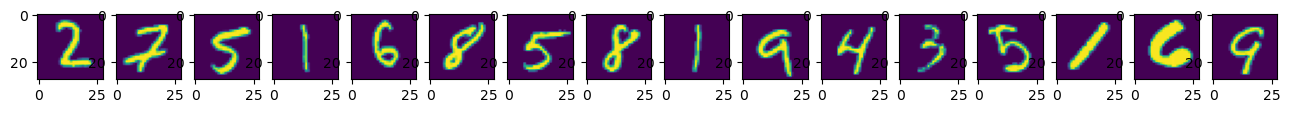

In [30]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform=transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
)

test_dataset = datasets.MNIST(root='../data',  download=True, train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

test_features, test_labels = next(iter(test_loader))

# plot the images
fig, axs = plt.subplots(nrows=1, ncols=16, figsize=(16, 1))

for i, splt in enumerate(axs):
    splt.imshow(test_features[i].reshape(28,28))

### Run inference by invoking the Azure function URL

The Azure function endpoint URL is of the format `function_app.azurewebsites.net`. We send the input to the function in the json format

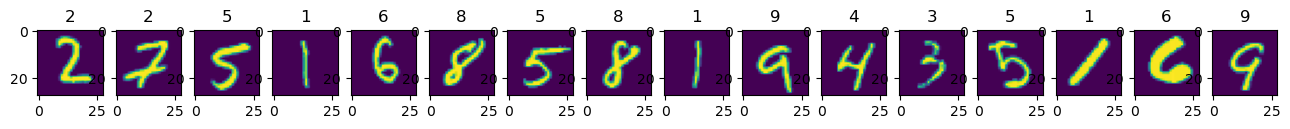

In [31]:
import requests, json

def to_numpy(tensor):
    return tensor.detach().cpu().numpy() if tensor.requires_grad else tensor.cpu().numpy()

url = f"https://{function_app}.azurewebsites.net/api/classify"
response = requests.post(url, 
                json.dumps({"data":to_numpy(test_features).tolist()})
            )
predictions = json.loads(response.text)['digits']

# plot the images
fig_out, axs_out = plt.subplots(nrows=1, ncols=16, figsize=(16, 1))

for i, splt in enumerate(axs_out):
    splt.imshow(test_features[i].reshape(28,28))
    splt.set_title(predictions[i])

## Clean Up

After we have tested that our model is running successfully on Azure functionapp, we delete the resources to avoid incurring unneccessary costs

In [32]:
!az group delete --name {resource_group_name} --yes

 - Finished ..

## Conclusion

In this notebook, we used prebuilt docker images with Amazon SageMaker to train an PyTorch model and deployed it as Azure Function

## Notebook CI Test Results

This notebook was tested in multiple regions. The test results are as follows, except for us-west-2 which is shown at the top of the notebook.


![This us-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-1/multicloud|train_and_deploy|pytorch|mnist-train-using-pytorch.ipynb)

![This us-east-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-2/multicloud|train_and_deploy|pytorch|mnist-train-using-pytorch.ipynb)

![This us-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-1/multicloud|train_and_deploy|pytorch|mnist-train-using-pytorch.ipynb)

![This ca-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ca-central-1/multicloud|train_and_deploy|pytorch|mnist-train-using-pytorch.ipynb)

![This sa-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/sa-east-1/multicloud|train_and_deploy|pytorch|mnist-train-using-pytorch.ipynb)

![This eu-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-1/multicloud|train_and_deploy|pytorch|mnist-train-using-pytorch.ipynb)

![This eu-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-2/multicloud|train_and_deploy|pytorch|mnist-train-using-pytorch.ipynb)

![This eu-west-3 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-3/multicloud|train_and_deploy|pytorch|mnist-train-using-pytorch.ipynb)

![This eu-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-central-1/multicloud|train_and_deploy|pytorch|mnist-train-using-pytorch.ipynb)

![This eu-north-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-north-1/multicloud|train_and_deploy|pytorch|mnist-train-using-pytorch.ipynb)

![This ap-southeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-1/multicloud|train_and_deploy|pytorch|mnist-train-using-pytorch.ipynb)

![This ap-southeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-2/multicloud|train_and_deploy|pytorch|mnist-train-using-pytorch.ipynb)

![This ap-northeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-1/multicloud|train_and_deploy|pytorch|mnist-train-using-pytorch.ipynb)

![This ap-northeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-2/multicloud|train_and_deploy|pytorch|mnist-train-using-pytorch.ipynb)

![This ap-south-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-south-1/multicloud|train_and_deploy|pytorch|mnist-train-using-pytorch.ipynb)
